Добавлен импульсный отклик


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats
from scipy.fft import irfft, rfftfreq
import warnings
warnings.filterwarnings('ignore')

In [10]:
def get_virtual_sources(source, room_width, room_height, max_order, reflection_coeffs_freq):
    virtual_sources = []
    for n in range(-max_order, max_order + 1):
        for m in range(-max_order, max_order + 1):
            order = abs(n) + abs(m)
            if order == 0 or order > max_order:
                continue
            
            left_count = abs(n) if n < 0 else 0
            right_count = n if n > 0 else 0
            bottom_count = abs(m) if m < 0 else 0
            top_count = m if m > 0 else 0
            
            effective_energy_factors = []
            for freq_idx in range(6):  # 6 частотных диапазонов
                factor = (
                    (reflection_coeffs_freq['left'][freq_idx] ** left_count) *
                    (reflection_coeffs_freq['right'][freq_idx] ** right_count) *
                    (reflection_coeffs_freq['bottom'][freq_idx] ** bottom_count) *
                    (reflection_coeffs_freq['top'][freq_idx] ** top_count)
                )
                effective_energy_factors.append(factor)
            
            if all(f == 0 for f in effective_energy_factors):
                continue
            
            x = n * room_width + (source[0] if n % 2 == 0 else room_width - source[0])
            y = m * room_height + (source[1] if m % 2 == 0 else room_height - source[1])
            virtual_sources.append({
                'pos': [x, y], 
                'order': order,
                'energy_factors': effective_energy_factors,
                'left_refl': left_count,
                'right_refl': right_count,
                'top_refl': top_count,
                'bottom_refl': bottom_count
            })
    return virtual_sources

In [11]:
def find_wall_intersections(p1, p2, room_width, room_height):
    intersections = []
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    if dx != 0:
        t = (0 - p1[0]) / dx
        if 0 <= t <= 1:
            y = p1[1] + t * dy
            if 0 <= y <= room_height:
                intersections.append((0, y, 'left', t))
        t = (room_width - p1[0]) / dx
        if 0 <= t <= 1:
            y = p1[1] + t * dy
            if 0 <= y <= room_height:
                intersections.append((room_width, y, 'right', t))

    if dy != 0:
        t = (0 - p1[1]) / dy
        if 0 <= t <= 1:
            x = p1[0] + t * dx
            if 0 <= x <= room_width:
                intersections.append((x, 0, 'bottom', t))
        t = (room_height - p1[1]) / dy
        if 0 <= t <= 1:
            x = p1[0] + t * dx
            if 0 <= x <= room_width:
                intersections.append((x, room_height, 'top', t))

    return sorted(intersections, key=lambda inter: inter[3])

In [12]:
def calculate_rt60_from_absorption(room_width, room_height, reflection_coeffs_freq):
    frequencies = [125, 250, 500, 1000, 2000, 4000]
    S = 2 * (room_width * room_height + room_width * 3 + room_height * 3)  # общая площадь
    V = room_width * room_height * 3  # объем (высота 3м)
    
    rt60_values = {}
    for idx, freq in enumerate(frequencies):
        absorption_left = 1 - reflection_coeffs_freq['left'][idx]
        absorption_right = 1 - reflection_coeffs_freq['right'][idx]
        absorption_top = 1 - reflection_coeffs_freq['top'][idx]
        absorption_bottom = 1 - reflection_coeffs_freq['bottom'][idx]
        
        avg_absorption = (absorption_left + absorption_right + absorption_top + absorption_bottom) / 4
        
        if avg_absorption > 0:
            rt60 = (0.161 * V) / (S * avg_absorption)
        else:
            rt60 = 2.0
        
        rt60_values[freq] = rt60
    
    return rt60_values

In [13]:
def compute_impulse_response_with_phase(room_width, room_height, source, receiver, max_order, reflection_coeffs_freq, fs=44100):
    freq_labels = [125, 250, 500, 1000, 2000, 4000]
    rt60_dict = calculate_rt60_from_absorption(room_width, room_height, reflection_coeffs_freq)
    max_rt60 = max(rt60_dict.values())
    
    ir_duration = max_rt60 * 1.5
    if ir_duration < 2.0:
        ir_duration = 2.0
    
    N_samples = int(fs * ir_duration)
    freqs_fft = rfftfreq(N_samples, d=1/fs)
    H_complex = np.zeros_like(freqs_fft, dtype=complex)
    
    speed_of_sound = 343
    
    # Вклад прямого пути
    direct_dist = np.linalg.norm(np.array(source) - np.array(receiver))
    direct_time = direct_dist / speed_of_sound
    direct_amplitude = 1.0 / direct_dist
    
    for i, f in enumerate(freqs_fft):
        if f == 0:
            continue
        phase_direct = -2 * np.pi * f * direct_time
        H_complex[i] += direct_amplitude * np.exp(1j * phase_direct)
    
    # Вклад отраженных путей
    virtual_sources = get_virtual_sources(source, room_width, room_height, max_order, reflection_coeffs_freq)
    
    for vs in virtual_sources:
        pos = vs['pos']
        energy_factors = vs['energy_factors']
        
        reflections = find_wall_intersections(pos, receiver, room_width, room_height)
        path_points = [pos] + [(ix[0], ix[1]) for ix in reflections] + [receiver]
        
        total_distance = sum(np.linalg.norm(np.array(path_points[i+1]) - np.array(path_points[i])) 
                            for i in range(len(path_points) - 1))
        
        travel_time = total_distance / speed_of_sound
        amplitude_factor = 1.0 / total_distance
        
        for i, f in enumerate(freqs_fft):
            if f == 0:
                continue
            
            if f <= freq_labels[0]:
                eff_refl_idx = 0
            elif f >= freq_labels[-1]:
                eff_refl_idx = len(freq_labels) - 1
            else:
                for j in range(len(freq_labels) - 1):
                    if freq_labels[j] <= f < freq_labels[j+1]:
                        w = (f - freq_labels[j]) / (freq_labels[j+1] - freq_labels[j])
                        sqrt_r1 = np.sqrt(energy_factors[j])
                        sqrt_r2 = np.sqrt(energy_factors[j+1])
                        effective_sqrt_refl = sqrt_r1 + w * (sqrt_r2 - sqrt_r1)
                        break
                else:
                    effective_sqrt_refl = np.sqrt(energy_factors[-1])
            
            if f <= freq_labels[0] or f >= freq_labels[-1]:
                eff_refl_idx = min(max(int(f/125) - 1, 0), 5)
                effective_sqrt_refl = np.sqrt(energy_factors[eff_refl_idx])
            
            total_amplitude = amplitude_factor * effective_sqrt_refl
            omega_t = 2 * np.pi * f * travel_time
            phase_contribution = total_amplitude * np.exp(-1j * omega_t)
            H_complex[i] += phase_contribution
    
    impulse_response = irfft(H_complex, n=N_samples)
    time_axis = np.linspace(0, ir_duration, N_samples)
    
    return impulse_response, time_axis, freqs_fft, H_complex, rt60_dict

In [14]:
def plot_room_with_paths(room_width, room_height, source, receiver, max_order, reflection_coeffs_freq):
    fig, ax = plt.subplots(figsize=(12, 10))
    room_patch = patches.Rectangle((0, 0), room_width, room_height, linewidth=2,
                                   edgecolor='orange', facecolor='none', linestyle='-')
    ax.add_patch(room_patch)
    ax.plot(source[0], source[1], 'ro', markersize=10, label='Источник')
    ax.plot(receiver[0], receiver[1], 'go', markersize=10, label='Приёмник')
    ax.plot([source[0], receiver[0]], [source[1], receiver[1]],
            color='purple', linestyle='-', linewidth=2, alpha=0.8, label='Прямой путь')

    virtual_sources = get_virtual_sources(source, room_width, room_height, max_order, reflection_coeffs_freq)

    for vs in virtual_sources:
        pos = vs['pos']
        reflections = find_wall_intersections(pos, receiver, room_width, room_height)
        path_points = [pos] + [(ix[0], ix[1]) for ix in reflections] + [receiver]
        
        if len(path_points) > 1:
            xs, ys = zip(*path_points)
            ax.plot(xs, ys, linestyle='-', linewidth=1, color='y', alpha=0.6)
        
        ax.plot(pos[0], pos[1], 'ro', markersize=4, alpha=0.6)
        
        offset_x = (pos[0] // room_width) * room_width
        offset_y = (pos[1] // room_height) * room_height
        virtual_room = patches.Rectangle(
            (offset_x, offset_y), room_width, room_height,
            linewidth=1, edgecolor='black', facecolor='none',
            linestyle='--', alpha=0.3
        )
        ax.add_patch(virtual_room)

    ax.set_xlim(-room_width, 2 * room_width)
    ax.set_ylim(-room_height, 2 * room_height)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=14)
    plt.title('Визуализация комнаты и путей отражений', fontsize=16)
    plt.show()

In [15]:
def draw_full_analysis(room_width, room_height, source, receiver, max_order, reflection_coeffs_freq):
    plot_room_with_paths(room_width, room_height, source, receiver, max_order, reflection_coeffs_freq)
    
    impulse_response, time_axis, freqs_fft, H_complex, rt60_dict = compute_impulse_response_with_phase(
        room_width, room_height, source, receiver, max_order, reflection_coeffs_freq
    )
    
    print("ТАБЛИЦА RT60 ДЛЯ ВСЕХ ЧАСТОТНЫХ ДИАПАЗОНОВ")
    print("Частота (Гц)\tRT60 (с)")
    print("-" * 25)
    for freq, rt60 in rt60_dict.items():
        print(f"{freq:<12}\t{rt60:.3f}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0,0].plot(time_axis[:len(impulse_response)//10], impulse_response[:len(impulse_response)//10])
    axes[0,0].set_title('Импульсный отклик h(t)')
    axes[0,0].set_xlabel('Время (с)')
    axes[0,0].set_ylabel('Амплитуда')
    axes[0,0].grid(True, alpha=0.3)
    
    magnitude_response = np.abs(H_complex)
    axes[0,1].semilogx(freqs_fft[:len(freqs_fft)//2], 20*np.log10(magnitude_response[:len(freqs_fft)//2] + 1e-12))
    axes[0,1].set_title('АЧХ (дБ)')
    axes[0,1].set_xlabel('Частота (Гц)')
    axes[0,1].set_ylabel('Амплитуда (дБ)')
    axes[0,1].grid(True, alpha=0.3)
    
    phase_response = np.angle(H_complex)
    axes[1,0].semilogx(freqs_fft[:len(freqs_fft)//2], phase_response[:len(freqs_fft)//2])
    axes[1,0].set_title('ФЧХ')
    axes[1,0].set_xlabel('Частота (Гц)')
    axes[1,0].set_ylabel('Фаза (рад)')
    axes[1,0].grid(True, alpha=0.3)
    
    peak_times = []
    peak_amplitudes = []
    threshold = 0.01 * np.max(np.abs(impulse_response))
    
    for i in range(1, len(impulse_response)-1):
        if (abs(impulse_response[i]) > threshold and 
            ((impulse_response[i] > impulse_response[i-1] and impulse_response[i] > impulse_response[i+1]) or
             (impulse_response[i] < impulse_response[i-1] and impulse_response[i] < impulse_response[i+1]))):
            peak_times.append(time_axis[i])
            peak_amplitudes.append(abs(impulse_response[i]))
    
    if len(peak_times) > 0:
        axes[1,1].scatter(peak_times[:min(50, len(peak_times))], peak_amplitudes[:min(50, len(peak_amplitudes))], alpha=0.6)
        axes[1,1].set_title('Пики импульсного отклика (временные задержки отражений)')
        axes[1,1].set_xlabel('Время (с)')
        axes[1,1].set_ylabel('Амплитуда')
        axes[1,1].grid(True, alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'Нет выраженных пиков', horizontalalignment='center', verticalalignment='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Пики импульсного отклика')
    
    plt.tight_layout()
    plt.show()
    
    return impulse_response, time_axis, freqs_fft, H_complex

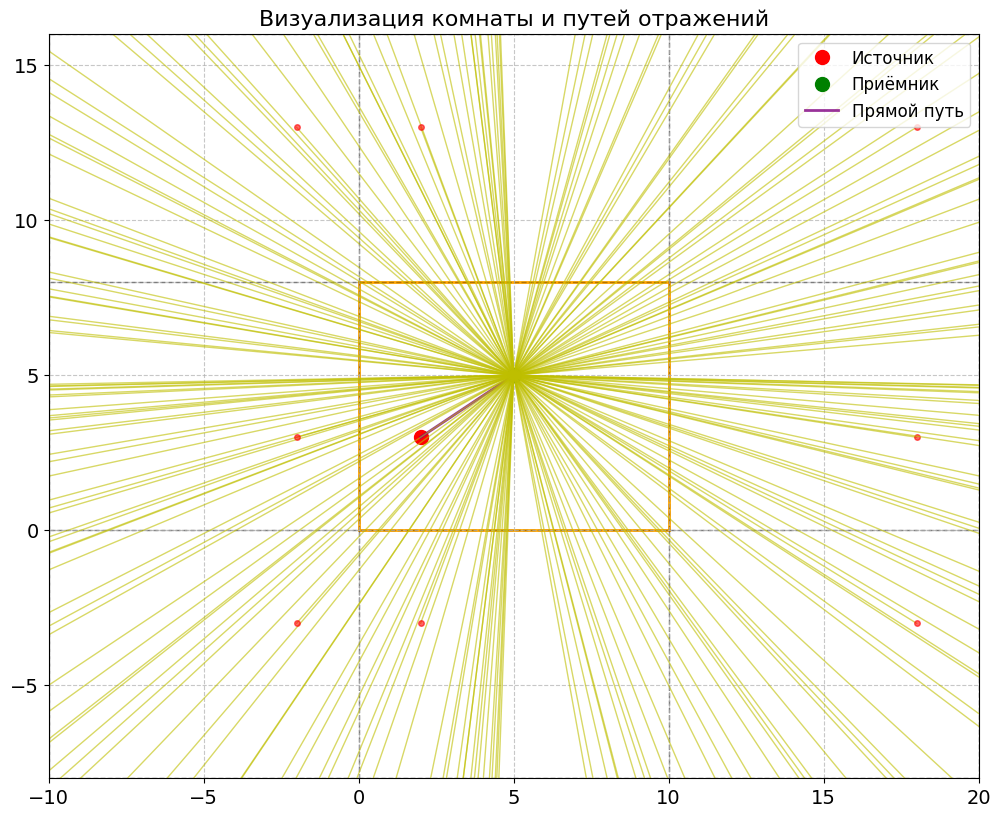

ТАБЛИЦА RT60 ДЛЯ ВСЕХ ЧАСТОТНЫХ ДИАПАЗОНОВ
Частота (Гц)	RT60 (с)
-------------------------
125         	0.240
250         	0.288
500         	0.360
1000        	0.481
2000        	0.721
4000        	1.442


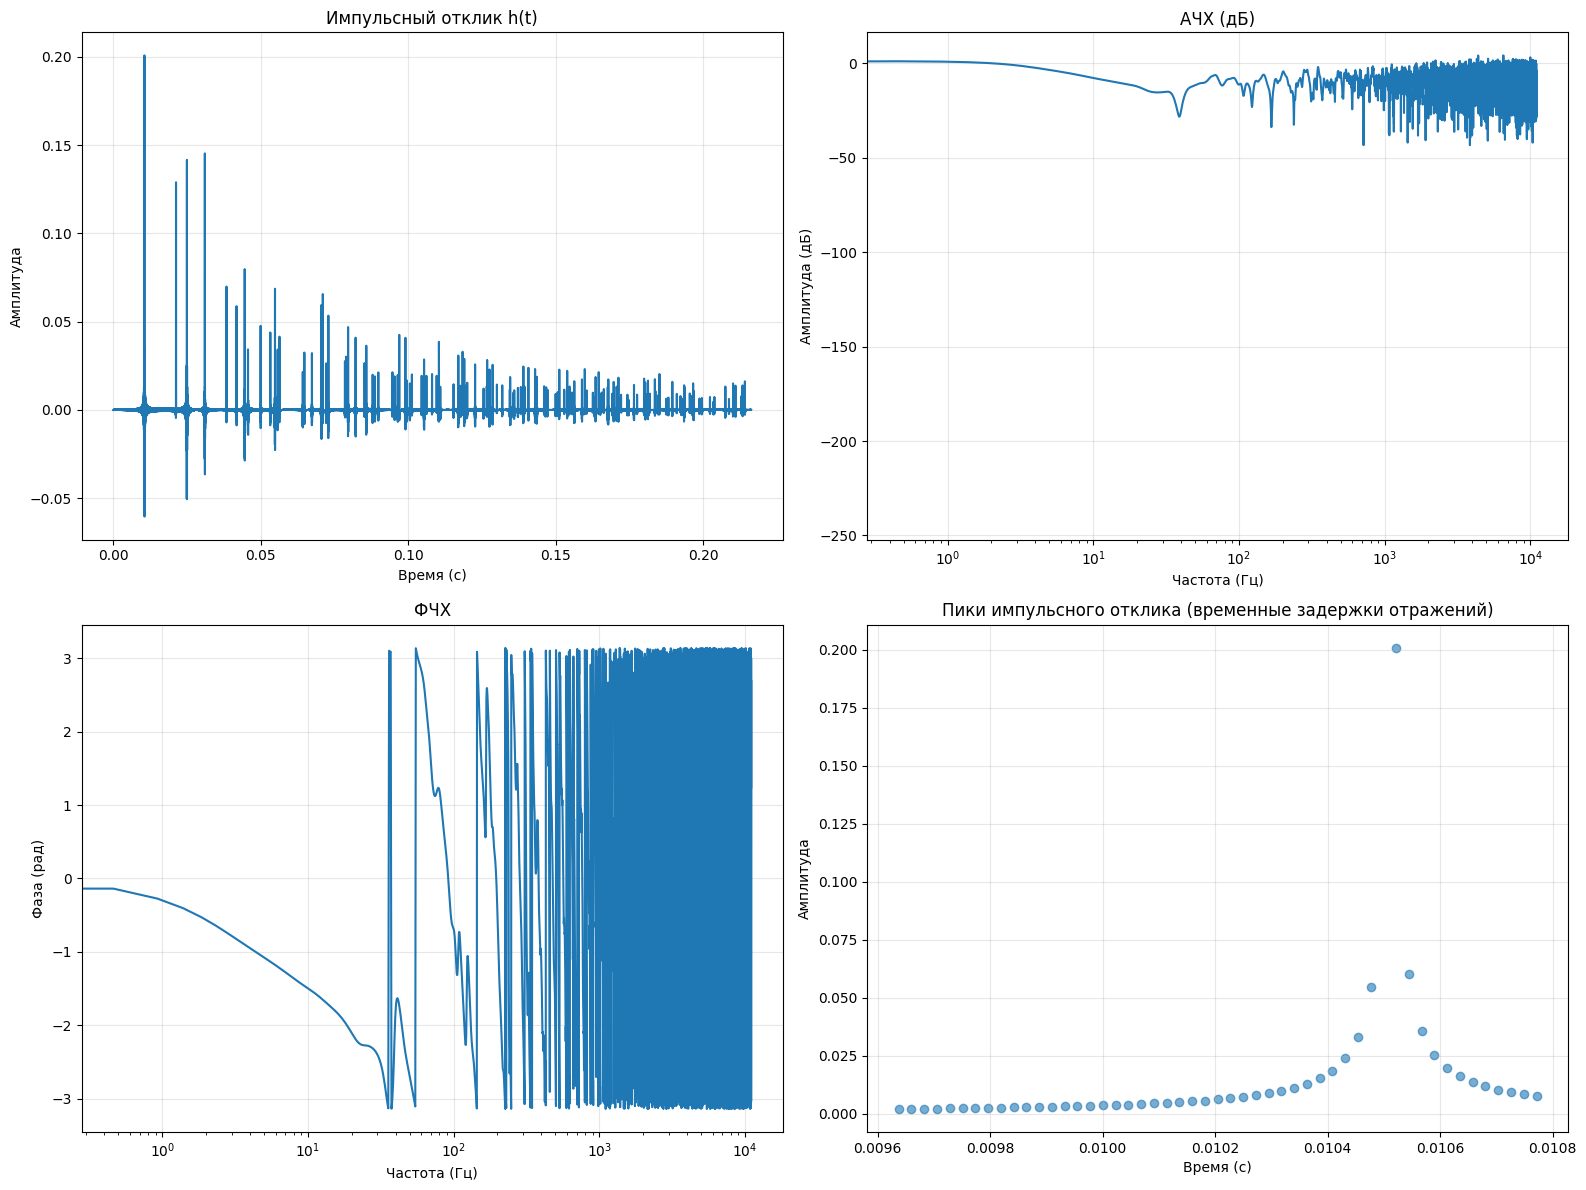

In [18]:
# Параметры
room_width = 10
room_height = 8
source = [2, 3]
receiver = [5, 5]
max_reflection_order = 10

left_freq = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
right_freq = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
top_freq = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
bottom_freq = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

reflection_coeffs_freq = {
    'left': left_freq,
    'right': right_freq,
    'top': top_freq,
    'bottom': bottom_freq
}

# Запуск анализа
impulse_resp, time_ax, freq_fft, H_comp = draw_full_analysis(
    room_width, room_height, source, receiver, max_reflection_order, reflection_coeffs_freq
)